# Half-Normal Distribution

`HalfNormal(scale)` is a continuous distribution on `[0, infinity)`: the distribution of `|X|` where `X` is a `Normal(0, scale)`. Because it puts all of its mass on the non-negative numbers and peaks at 0, it is a common choice of prior for a standard deviation or other scale parameter in Bayesian modeling.

In [1]:
from symbulate import *

## Draw a value from a Half-Normal distribution

In [2]:
HalfNormal(scale=2).draw()

1.1129580545314224

## Theoretical mean, variance, and standard deviation

The mean is `scale * sqrt(2 / pi)`, and the variance is `scale ** 2 * (1 - 2 / pi)`. Note the mean is *not* 0 and the standard deviation is *not* `scale` -- folding the negative half of the normal onto the positive side moves both.

In [3]:
HalfNormal(scale=2).mean(), HalfNormal(scale=2).var(), HalfNormal(scale=2).sd()

(np.float64(1.5957691216057308),
 np.float64(1.4535209105296745),
 np.float64(1.2056205499781738))

## Assign and simulate a random variable

In [4]:
H = RV(HalfNormal(scale=2))
H.sim(10000)

0,0.5916951037624444
1,1.3773624125882986
2,1.0700486689522568
3,1.8379533574158298
4,0.3171384000097331
5,1.7459137667745135
6,3.2394268499918013
7,3.993434087812433
8,1.8038364607127313
...,...
9999,0.3659578684681066


## Plot the pdf

The density is highest at 0 and decreases from there -- it is the right half of a normal bell curve, doubled in height so the area still totals 1.

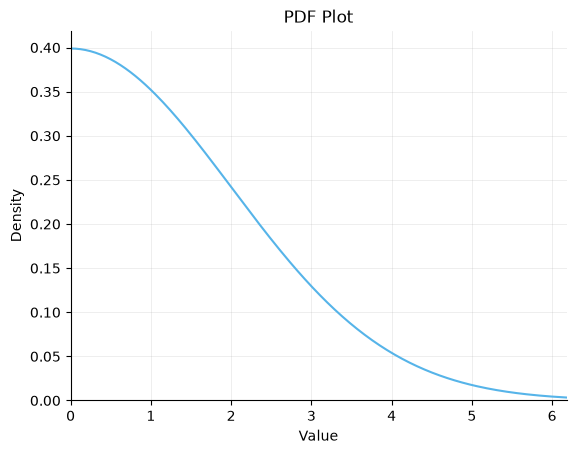

In [5]:
HalfNormal(scale=2).plot()

## Plot the CDF

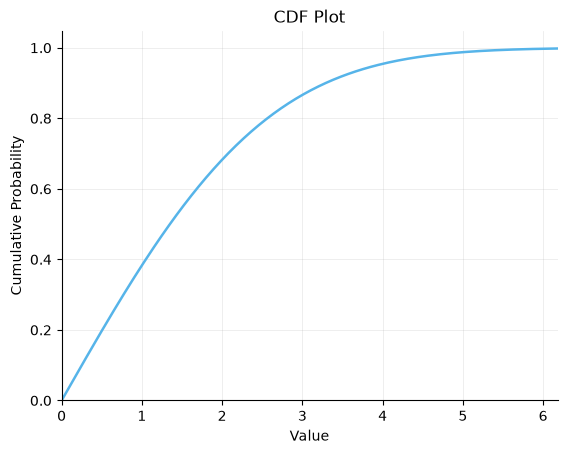

In [6]:
HalfNormal(scale=2).plot(cdf=True)

## Scale parameter changes the spread

A smaller scale concentrates the distribution near 0; a larger one spreads it further out.

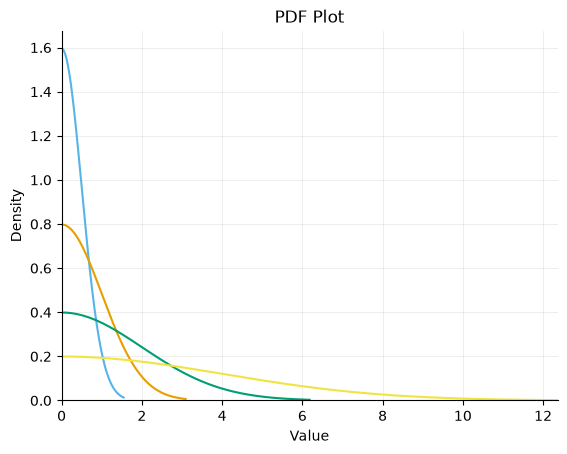

In [7]:
for s in [0.5, 1, 2, 4]:
    HalfNormal(scale=s).plot()

## Relationship: the absolute value of a Normal

This is the definition of the distribution. Simulating `|X|` for `X` a `Normal(0, 2)` matches the `HalfNormal(scale=2)` curve.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


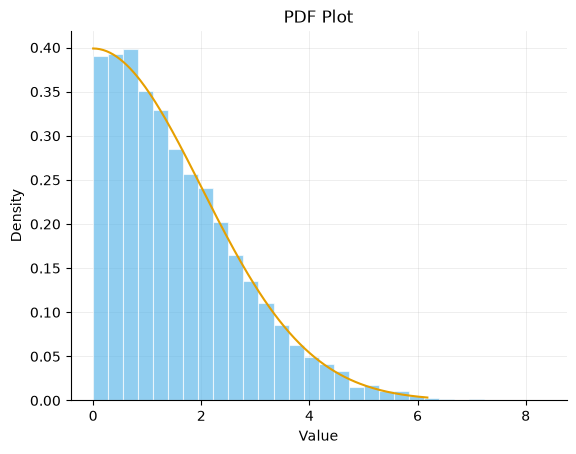

In [8]:
X = RV(Normal(mean=0, sd=2))
X.apply(abs).sim(10000).plot()
HalfNormal(scale=2).plot()

## Comparison: Half-Normal and Rayleigh

These two are relatives, not the same distribution. A `HalfNormal` is the distance from 0 of a *single* standard normal, while a `Rayleigh` is the distance from the origin of a *pair* of independent standard normals (`sqrt(X ** 2 + Y ** 2)`). Adding the second coordinate makes a value near 0 unlikely, so the Rayleigh density starts at 0 and has an interior peak, while the Half-Normal peaks at 0.

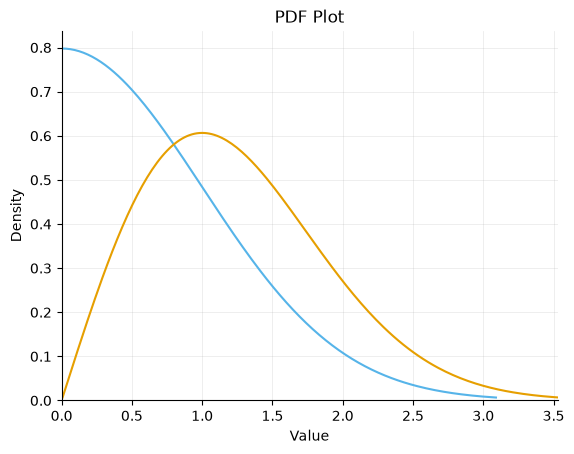

In [9]:
HalfNormal(scale=1).plot()
Rayleigh().plot()